In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [7]:
df =pd.read_csv("noisy_curvefit_data.csv")
print(df.shape)
df.head()

(100, 6)


,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
0,-1.000000,11.624419,8.296963,12.201067,7.811725,3.155566
1,-0.929293,10.377466,9.674440,12.198084,8.275006,7.518855
2,-0.858586,10.585100,9.251983,13.186565,12.926586,9.963630
3,-0.787879,10.913928,7.786344,12.552304,11.832379,9.625801
4,-0.717172,8.640287,8.551869,4.741432,8.790834,6.624113


In [8]:
df.tail()

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
95,5.717172,-1.411918,0.822231,-2.027132,-1.825106,2.746147
96,5.787879,0.344879,-1.718956,2.747559,-6.803779,-5.137472
97,5.858586,0.307133,0.353528,0.967976,5.461567,-0.905616
98,5.929293,0.048657,0.159961,2.482130,-0.414616,-4.334548
99,6.000000,-0.193438,-2.244792,1.930035,4.992414,-6.872850


In [4]:
"""
a) shape (100, 6)
b) 100 rows, 6 columns
c) column names: x, y_noise_1, y_noise_2, y_noise_3, y_noise_4, y_noise_5
"""

'\na) shape (100, 6)\nb) 100 rows, 6 columns\nc) column names: x, y_noise_1, y_noise_2, y_noise_3, y_noise_4, y_noise_5\n'

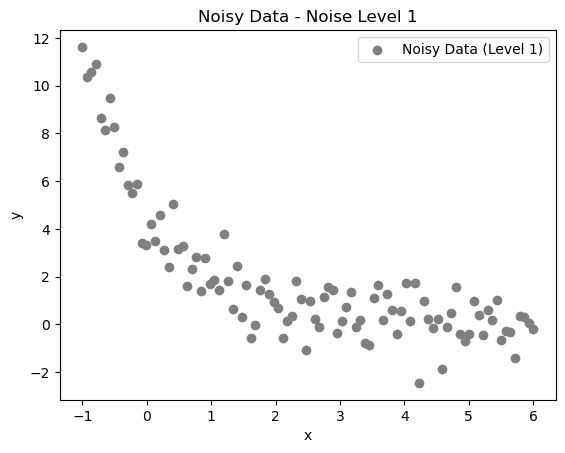

In [12]:
x=df["x"]
y_noise_1=df["y_noise_1"]

plt.scatter(x, y_noise_1, color='gray', label='Noisy Data (Level 1)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Noisy Data - Noise Level 1')
plt.legend()
plt.show()

In [13]:
##2.2

In [14]:
def model(x, A, k):
    return A*np.exp(-k *x)
p0 = [1, 1]
popt, pcov = curve_fit(model, x, y_noise_1, p0=p0)
A_fit, k_fit = popt
print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")


Fit: y = 4.71 * e^(-0.92 * x)


In [15]:
residuals = y_noise_1 - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof

print(f"Reduced Chi-Squared: {chi2_reduced:.2f}")


Reduced Chi-Squared: 0.79


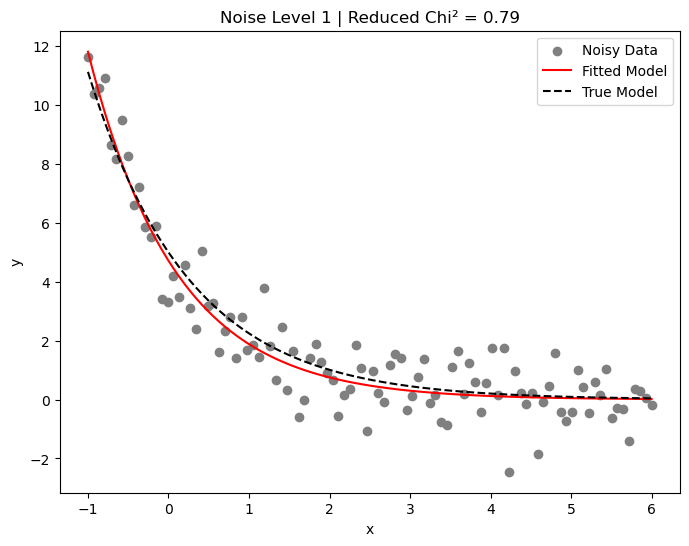

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(x, y_noise_1, color='gray', label='Noisy Data')
plt.plot(x, model(x, A_fit, k_fit), color='red', label='Fitted Model')
plt.plot(x, model(x, 5, 0.8), 'k--', label='True Model')  # true model
plt.title(f"Noise Level 1 | Reduced Chi² = {chi2_reduced:.2f}")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [19]:
x = df["x"]
y_noise_1 = df["y_noise_1"]
y_noise_2 = df["y_noise_2"]
y_noise_3 = df["y_noise_3"]
y_noise_4 = df["y_noise_4"]
y_noise_5 = df["y_noise_5"]

In [ ]:
#2.3

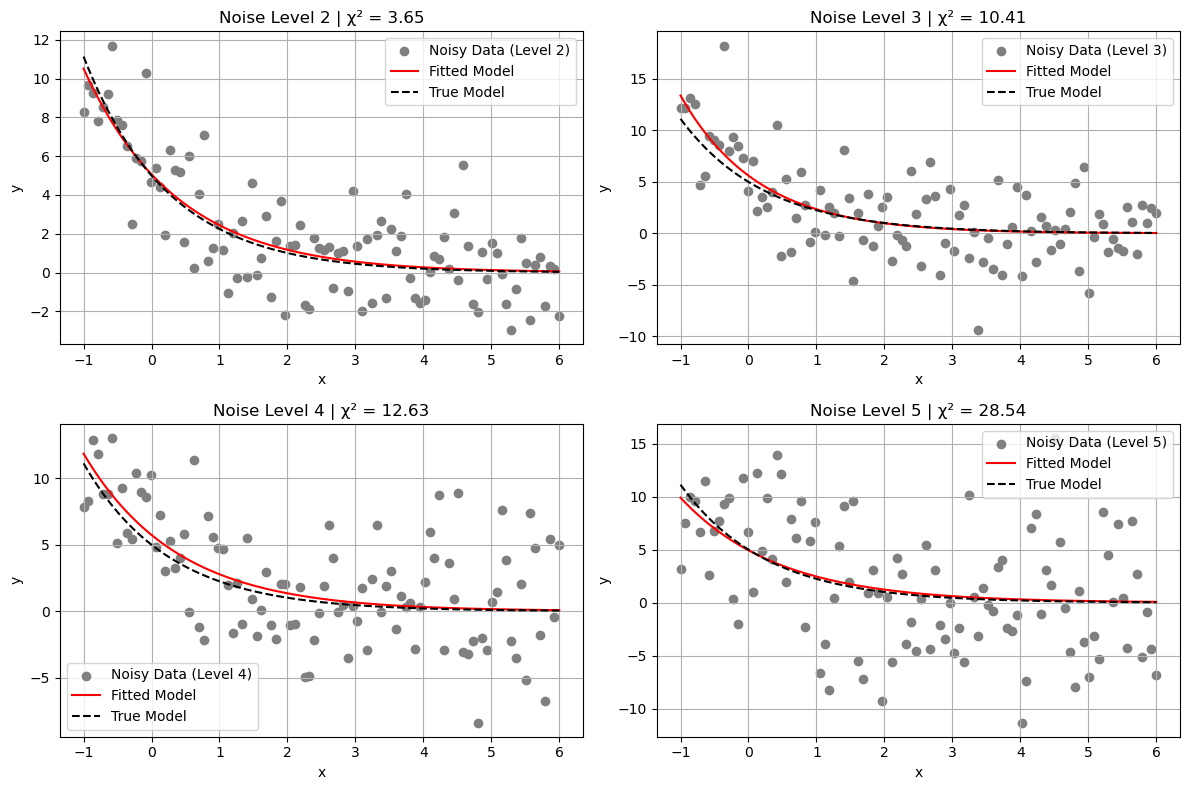

In [20]:
def fit_model(x, y):
    p0 = [1, 1]
    popt, pcov = curve_fit(model, x, y, p0=p0)
    A_fit, k_fit = popt
    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof
    return A_fit, k_fit, chi2_reduced

y_noises = [y_noise_1, y_noise_2, y_noise_3, y_noise_4, y_noise_5]

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

for i, y in enumerate(y_noises[1:]):  
    A_fit, k_fit, chi2_reduced = fit_model(x, y)
    axs[i].scatter(x, y, color='gray', label=f'Noisy Data (Level {i+2})')
    axs[i].plot(x, model(x, A_fit, k_fit), color='red', label='Fitted Model')
    axs[i].plot(x, model(x, 5, 0.8), 'k--', label='True Model')
    axs[i].set_title(f"Noise Level {i+2} | χ² = {chi2_reduced:.2f}")
    axs[i].set_xlabel('x')
    axs[i].set_ylabel('y')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
"""
a) As noise increases, the red fitted line deviates more from the true model, and reduced Chi^2
    increases with noise because the fit becomes less accurate
b) when noise=1, the fit closely matches the true model, hence reduced chi^2 would be close to one
    meaning a good fit
c) When noise is 5, chi^2 is much greater than 1, leads to a poor fit
"""

In [22]:
results = []
for i, y in enumerate(y_noises):
    A_fit, k_fit, chi2_reduced = fit_model(x, y)
    results.append([i+1, A_fit, k_fit, chi2_reduced])

results_df = pd.DataFrame(results, columns=["Noise Level", "A_fit", "k_fit", "Reduced Chi²"])
print(results_df)

results_df.to_csv("noisy_parameters.csv", index=False)

   Noise Level     A_fit     k_fit  Reduced Chi²
0            1  4.714814  0.918308      0.790673
1            2  5.063889  0.730396      3.649382
2            3  5.609396  0.870372     10.410207
3            4  5.738727  0.725965     12.626832
4            5  4.943458  0.695012     28.538124
